#CS-4403 Project Implementation

#Team: Fady Elgohary 3762991 & Darin Thomson 3776723

In [51]:
#import packages & libraries
import pandas as pd
import math
import numpy as np

In [52]:
#to import our dataset
df = pd.read_csv("/content/Data.csv")

In [53]:
#to display the first few columns and rows of our uncleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 68 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   Unnamed: 0                                                                   112 non-null    int64  
 1   Author and Year                                                              112 non-null    object 
 2   Percent male (%)                                                             112 non-null    int64  
 3   Race with largest number                                                     112 non-null    object 
 4   Age (years)                                                                  112 non-null    float64
 5   Height (cm)                                                                  110 non-null    float64
 6   Weight (kg)                               

In [54]:
#code to check how many null values are found in each of the rows & columns
null_data = df.isnull().sum()
print (null_data[null_data > 0])

Height (cm)                                                                     2
Weight (kg)                                                                     2
Protein intake before intervention (g/kg/day)                                  32
Protein intake before intervention (g/day)                                     32
Protein intake during intervention (not include supplementation) (g/kg/day)    68
Protein intake during intervention (not include supplementation) (g/day)       68
Protein intake during intervention (include supplementation) (g/kg/day)        45
Protein intake during intervention (include supplementation) (g/day)           43
Energy intake before intervention (g/kg/day)                                   32
Energy intake before intervention (g/day)                                      32
Energy intake during intervention (not include supplementation) (g/kg/day)     72
Energy intake during intervention (not include supplementation) (g/day)        72
Energy intake du

## Step 1: Data Type Fixes

After inspecting `df.info()`, two columns are stored as `object` but should be numeric:
- **`Control Total`** → should be `int64` (mirrors `Experimental Total`)
- **`95CI Upper`** → should be `float64` (mirrors `95CI Lower`)

All other columns already carry the correct dtype.

In [55]:
# To identify columns with wrong datatypes
print("Before fix:")
print(df[['Control Total', '95CI Upper']].dtypes)
print()



# to convert the 'Control Total' column into an integer datatype value
df['Control Total'] = pd.to_numeric(df['Control Total'], errors='coerce').astype('Int64')


# convert the '95CI Upper' to a floating point value
df['95CI Upper'] = pd.to_numeric(df['95CI Upper'], errors='coerce')


print("After fix:")
print(df[['Control Total', '95CI Upper']].dtypes)

Before fix:
Control Total    object
95CI Upper       object
dtype: object

After fix:
Control Total      Int64
95CI Upper       float64
dtype: object


## Step 2: Drop Irrelevant Columns

Two categories of columns have been dropped:

1. **`Unnamed columns: 0`**: because an unnamed column is a duplicate row index with no predictive value.
2. **Columns with >50% missing values** (out of 112 rows): as these kinds of columns are too sparse to be useful in modeling:
   | Column Name| No. of Nulls | % Missing |
   |---|---|---|
   | Protein intake during intervention *(not include suppl.)* (g/kg/day) | 68 | 60.7 % |
   | Protein intake during intervention *(not include suppl.)* (g/day) | 68 | 60.7 % |
   | Energy intake during intervention *(not include suppl.)* (g/kg/day) | 72 | 64.3 % |
   | Energy intake during intervention *(not include suppl.)* (g/day) | 72 | 64.3 % |

In [56]:
#  To drop the pure index column
df.drop(columns=['Unnamed: 0'], inplace=True)


#  To drop all the columns with >50% missing values
threshold = 0.50  # drop if more than 50% of values are null
cols_before = df.shape[1]


# fraction of nulls per column
missing_frac = df.isnull().mean()
cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()


print(f"Columns dropped for exceeding {threshold*100:.0f}% missing threshold:")
for c in cols_to_drop:
    print(f"  '{c}'  ({df[c].isnull().sum()} / {len(df)} nulls = {missing_frac[c]*100:.1f}%)")


df.drop(columns=cols_to_drop, inplace=True)


Columns dropped for exceeding 50% missing threshold:
  'Protein intake during intervention (not include supplementation) (g/kg/day)'  (68 / 112 nulls = 60.7%)
  'Protein intake during intervention (not include supplementation) (g/day)'  (68 / 112 nulls = 60.7%)
  'Energy intake during intervention (not include supplementation) (g/kg/day)'  (72 / 112 nulls = 64.3%)
  'Energy intake during intervention (not include supplementation) (g/day)'  (72 / 112 nulls = 64.3%)


## Step 3: Fill in the Null Values

Strategy applied:
- **Numeric columns** → were filled with the column **median**  
  *(median is preferred over mean because biomedical measurements such as protein/energy intake are often right-skewed and contain outliers)*
- **Categorical / object columns** → were filled with the column **mode** (most frequent value)

In [57]:
# Code to separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
object_cols  = df.select_dtypes(include=['object']).columns.tolist()

# To fill in numeric nulls with the median of that specific column
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val, inplace=True)


# Code to verify no nulls remain
remaining_nulls = df.isnull().sum().sum()
print(f"\nTotal remaining null values: {remaining_nulls}")


Total remaining null values: 3584


## Final Run: To ensure the Dataset is Clean & Ready to Use

In [58]:
#To display info of the cleaned dataset and cross-check for any inconsistencies
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 63 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   Author and Year                                                          112 non-null    object 
 1   Percent male (%)                                                         112 non-null    int64  
 2   Race with largest number                                                 112 non-null    object 
 3   Age (years)                                                              112 non-null    float64
 4   Height (cm)                                                              0 non-null      object 
 5   Weight (kg)                                                              0 non-null      object 
 6   BMI (kg/m2)                                                              1

In [59]:
#to check the number of rows in our cleaned dataset and the corresponding columns
df.isnull().sum()

,0
Author and Year,0
Percent male (%),0
Race with largest number,0
Age (years),0
Height (cm),112
...,...
Protein intake (g/kg/day),112
LBM change (kg),0
LBM change per week (kg/wk),0
Relative LBM change,112


---
## The Bug Fixing Part

The imputation cell above contains a bug which we initially didn't notice but implemented soon later: `df[col] = df[col].fillna(value, inplace=True)` assigns `None` to the column because `fillna(..., inplace=True)` returns `None`. The corrected version of this is displayed below.
The clean dataset is rebuilt from scratch here so every step is transparent.

In [60]:
# Re-run full clean pipeline with the bug fixed
import pandas as pd
import numpy as np


df = pd.read_csv('/content/Data.csv')


# Step 1: datatype fixes
df['Control Total'] = pd.to_numeric(df['Control Total'], errors='coerce').astype('Int64')
df['95CI Upper']    = pd.to_numeric(df['95CI Upper'],    errors='coerce')


# Step 2: drop index column + columns with >50% missing
df.drop(columns=['Unnamed: 0'], inplace=True)
missing_frac  = df.isnull().mean()
cols_to_drop  = missing_frac[missing_frac > 0.50].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)


# Step 3: imputation  ← BUG FIX: do NOT assign the result when inplace=True
# Correct pattern:  df[col].fillna(value, inplace=True)
# NOT: df[col] = df[col].fillna(value, inplace=True)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
object_cols  = df.select_dtypes(include='object').columns.tolist()


for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())   # ← correct


for col in object_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])  # ← fill categorical with mode


print(f'Clean dataset — rows: {df.shape[0]}, columns: {df.shape[1]}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')


Clean dataset — rows: 112, columns: 63
Remaining nulls: 0


---
## Step 4: Exploratory Data Analysis (EDA)

Before modeling we visualise the distributions of the most important variables and how they relate to our target: **LBM change (kg)**.

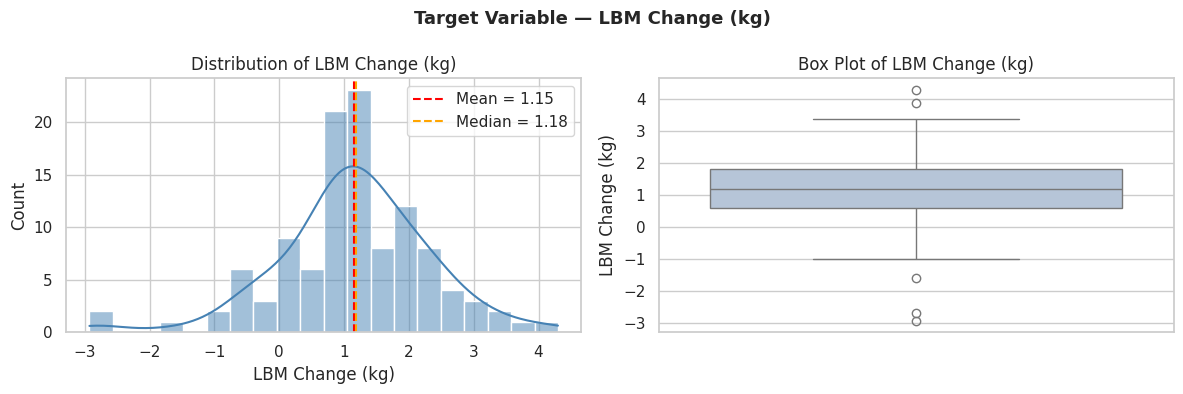

count    112.000
mean       1.150
std        1.163
min       -2.930
25%        0.600
50%        1.180
75%        1.825
max        4.300
Name: LBM change (kg), dtype: float64


In [61]:
#import necessary packages
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


sns.set_theme(style='whitegrid', palette='muted')


# 4a: Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


sns.histplot(df['LBM change (kg)'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['LBM change (kg)'].mean(),   color='red',    linestyle='--', label=f"Mean = {df['LBM change (kg)'].mean():.2f}")
axes[0].axvline(df['LBM change (kg)'].median(), color='orange', linestyle='--', label=f"Median = {df['LBM change (kg)'].median():.2f}")
axes[0].set_title('Distribution of LBM Change (kg)')
axes[0].set_xlabel('LBM Change (kg)')
axes[0].legend()


sns.boxplot(y=df['LBM change (kg)'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('Box Plot of LBM Change (kg)')
axes[1].set_ylabel('LBM Change (kg)')


plt.suptitle('Target Variable — LBM Change (kg)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(df['LBM change (kg)'].describe().round(3))


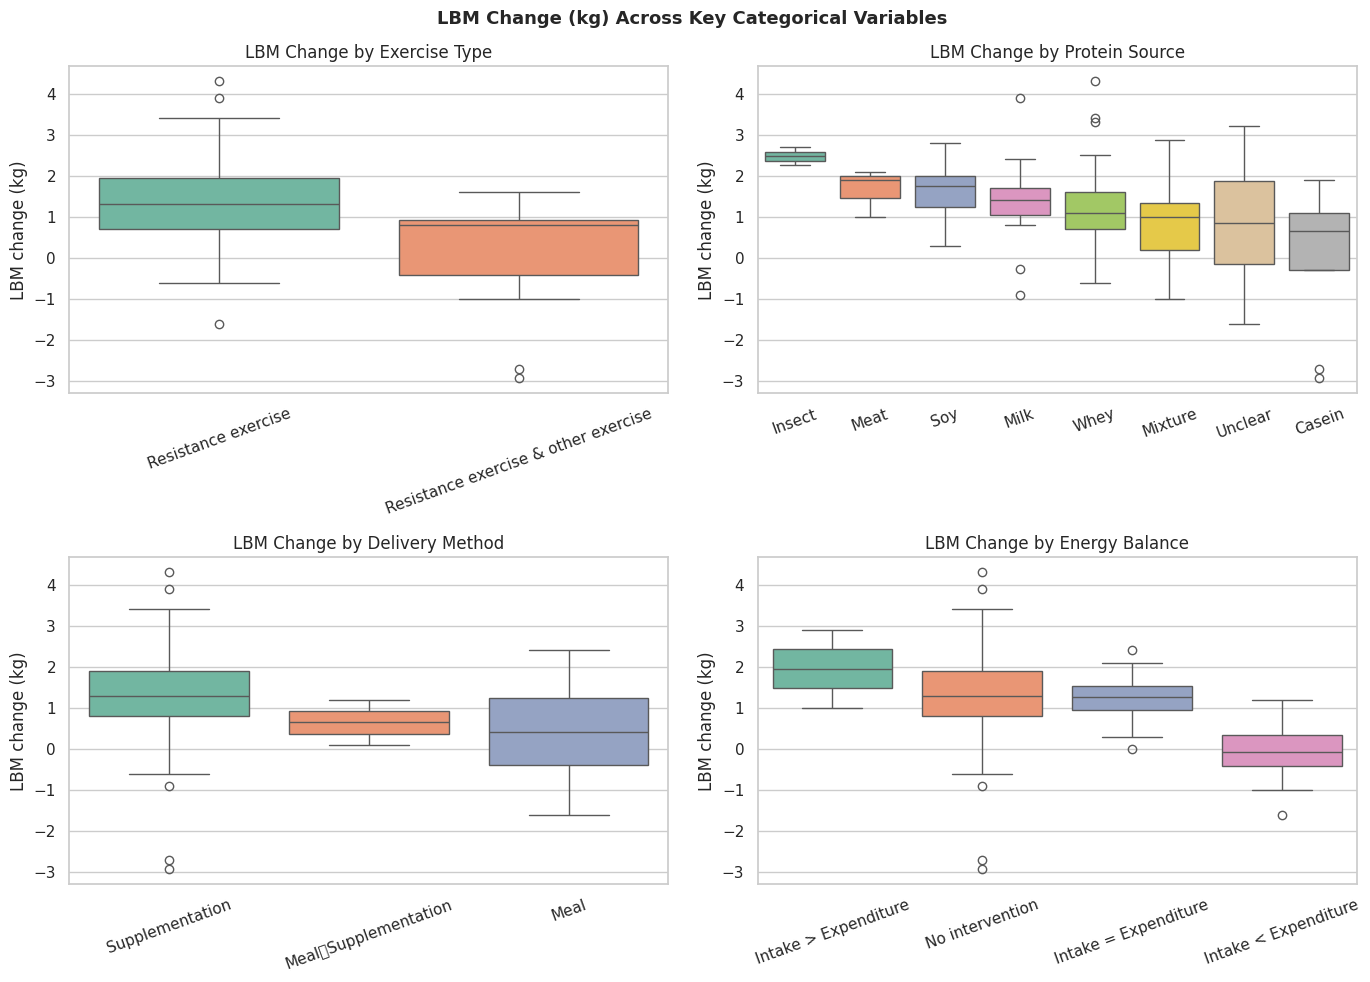

In [62]:
# 4b: LBM Change by categorical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


cat_vars = [
    ('Type ofExercise',       'Exercise Type'),
    ('Protein source',        'Protein Source'),
    ('Meal or Supplementation','Delivery Method'),
    ('Energy balance',        'Energy Balance'),
]


for ax, (col, label) in zip(axes.flat, cat_vars):
    order = df.groupby(col)['LBM change (kg)'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='LBM change (kg)', order=order, ax=ax, palette='Set2')
    ax.set_title(f'LBM Change by {label}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)


plt.suptitle('LBM Change (kg) Across Key Categorical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


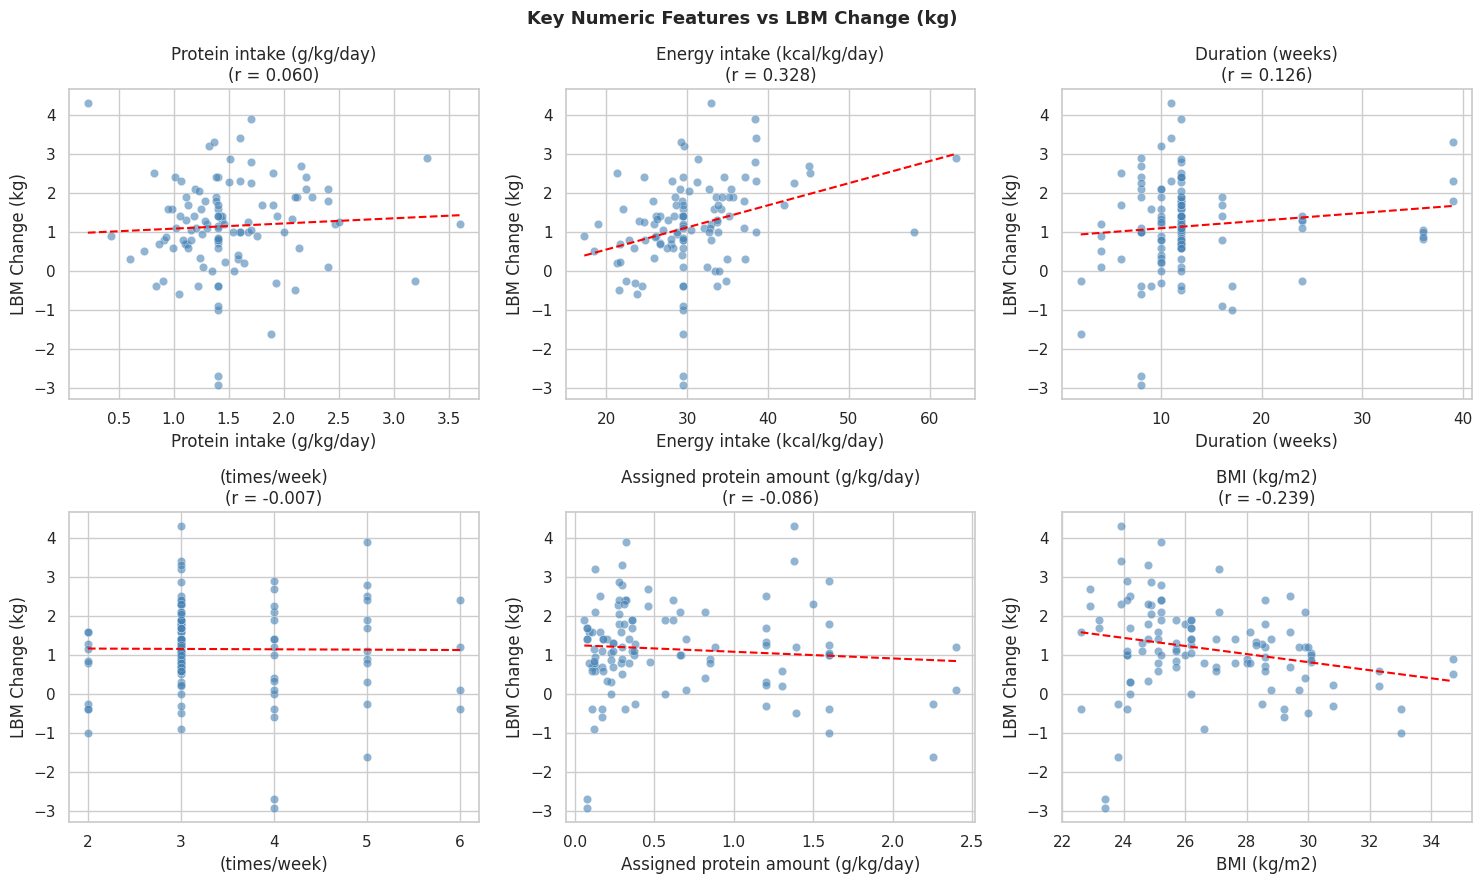

In [63]:
# 4c: Key numeric relationships with LBM change
key_features = [
    'Protein intake (g/kg/day)',
    'Energy intake (kcal/kg/day)',
    'Duration (weeks)',
    '(times/week)',
    'Assigned protein amount (g/kg/day)',
    'BMI (kg/m2)',
]


fig, axes = plt.subplots(2, 3, figsize=(15, 9))


for ax, feat in zip(axes.flat, key_features):
    ax.scatter(df[feat], df['LBM change (kg)'], alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.3)
    m, b = np.polyfit(df[feat], df['LBM change (kg)'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
    r = df[[feat, 'LBM change (kg)']].corr().iloc[0, 1]
    ax.set_title(f'{feat}\n(r = {r:.3f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('LBM Change (kg)')


plt.suptitle('Key Numeric Features vs LBM Change (kg)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


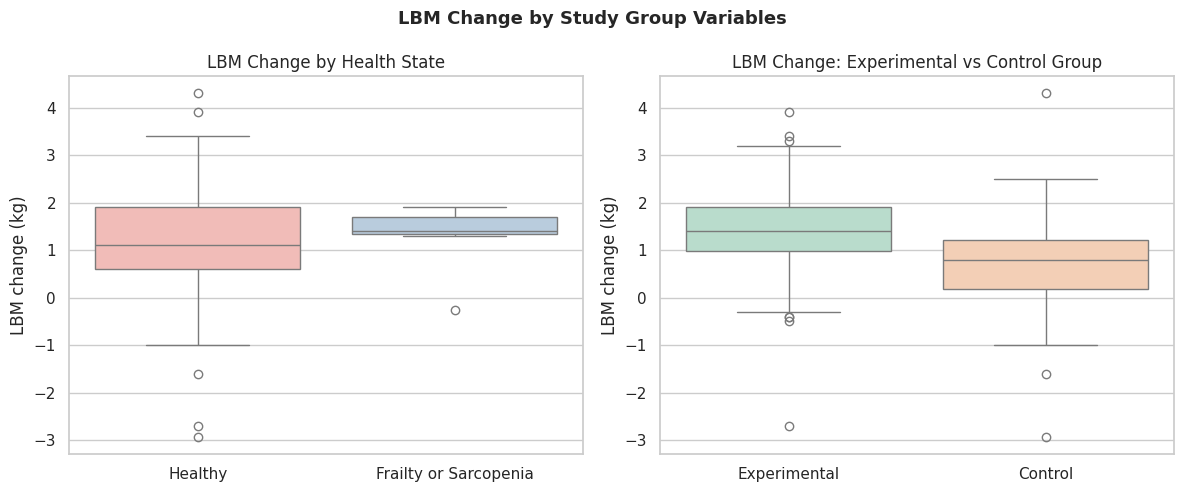

In [64]:
# 4d: LBM change by Health State and Group (Experimental vs Control)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(data=df, x='Health state', y='LBM change (kg)', ax=axes[0], palette='Pastel1')
axes[0].set_title('LBM Change by Health State')
axes[0].set_xlabel('')


sns.boxplot(data=df, x='Group', y='LBM change (kg)', ax=axes[1], palette='Pastel2')
axes[1].set_title('LBM Change: Experimental vs Control Group')
axes[1].set_xlabel('')


plt.suptitle('LBM Change by Study Group Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 5: Correlation Analysis

We compute the Pearson correlation of all numeric features against the target (`LBM change (kg)`) and visualise the top relationships via a heatmap.

> **Note on leakage columns:** `Relative LBM change`, `LBM change per week`, `Relative LBM change per week`, `Experimental Mean`, and `Control Mean` are all *derived from* LBM change — including them in a model would constitute data leakage. They are excluded from all modeling steps below.

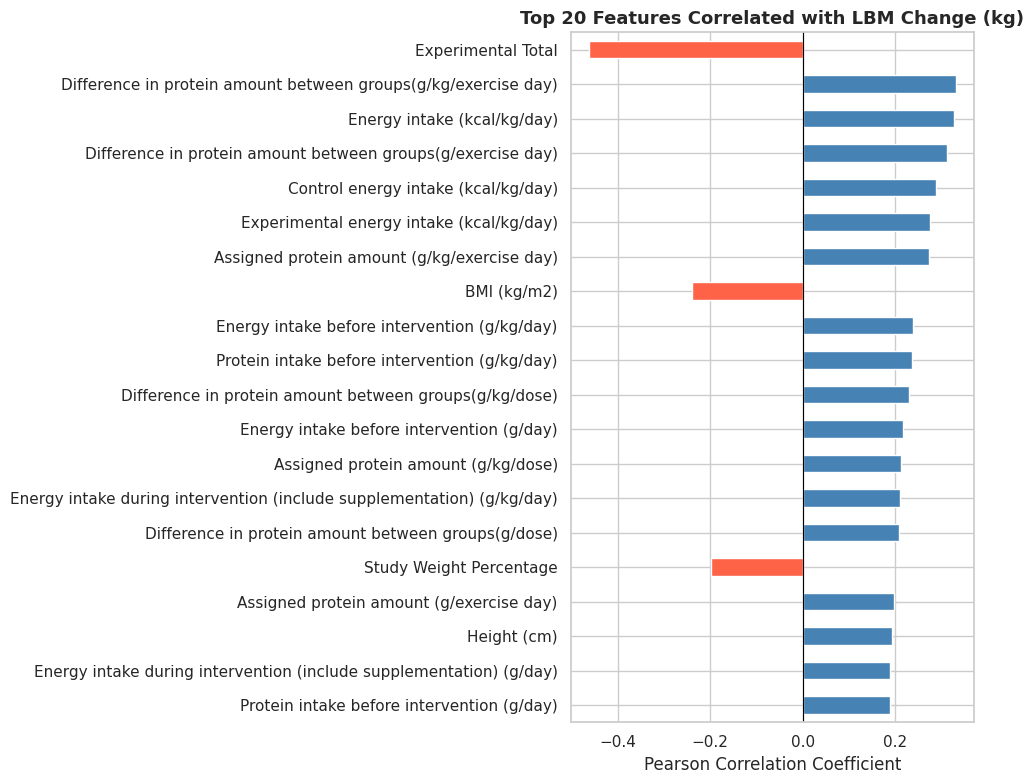

Top 15 correlations with LBM change (kg):
Experimental Total                                                       -0.462
Difference in protein amount between groups(g/kg/exercise day)            0.331
Energy intake (kcal/kg/day)                                               0.328
Difference in protein amount between groups(g/exercise day)               0.311
Control energy intake (kcal/kg/day)                                       0.288
Experimental energy intake (kcal/kg/day)                                  0.274
Assigned protein amount (g/kg/exercise day)                               0.273
BMI (kg/m2)                                                              -0.239
Energy intake before intervention (g/kg/day)                              0.238
Protein intake before intervention (g/kg/day)                             0.236
Difference in protein amount between groups(g/kg/dose)                    0.229
Energy intake before intervention (g/day)                                 0.21

In [65]:
# Columns derived from the target: this must exclude to avoid data leakage
leakage_cols = [
    'Relative LBM change',
    'Relative LBM change per week',
    'LBM change per week (kg/wk)',
    'Experimental Mean (kg)',
    'Control Mean (kg)',
    'Mean Difference',
    '95CI Lower',
    '95CI Upper',
]


# Also exclude non-informative identifiers
id_cols = ['Author and Year', 'Study or Subgroup']


numeric_df = df.select_dtypes(include='number').drop(
    columns=[c for c in leakage_cols if c in df.columns], errors='ignore'
)


# Correlation with target
corr_target = numeric_df.corr()['LBM change (kg)'].drop('LBM change (kg)').sort_values(key=abs, ascending=False)


# Top 20 correlations bar chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_target.head(20)]
corr_target.head(20).plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Features Correlated with LBM Change (kg)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


print('Top 15 correlations with LBM change (kg):')
print(corr_target.head(15).round(3).to_string())


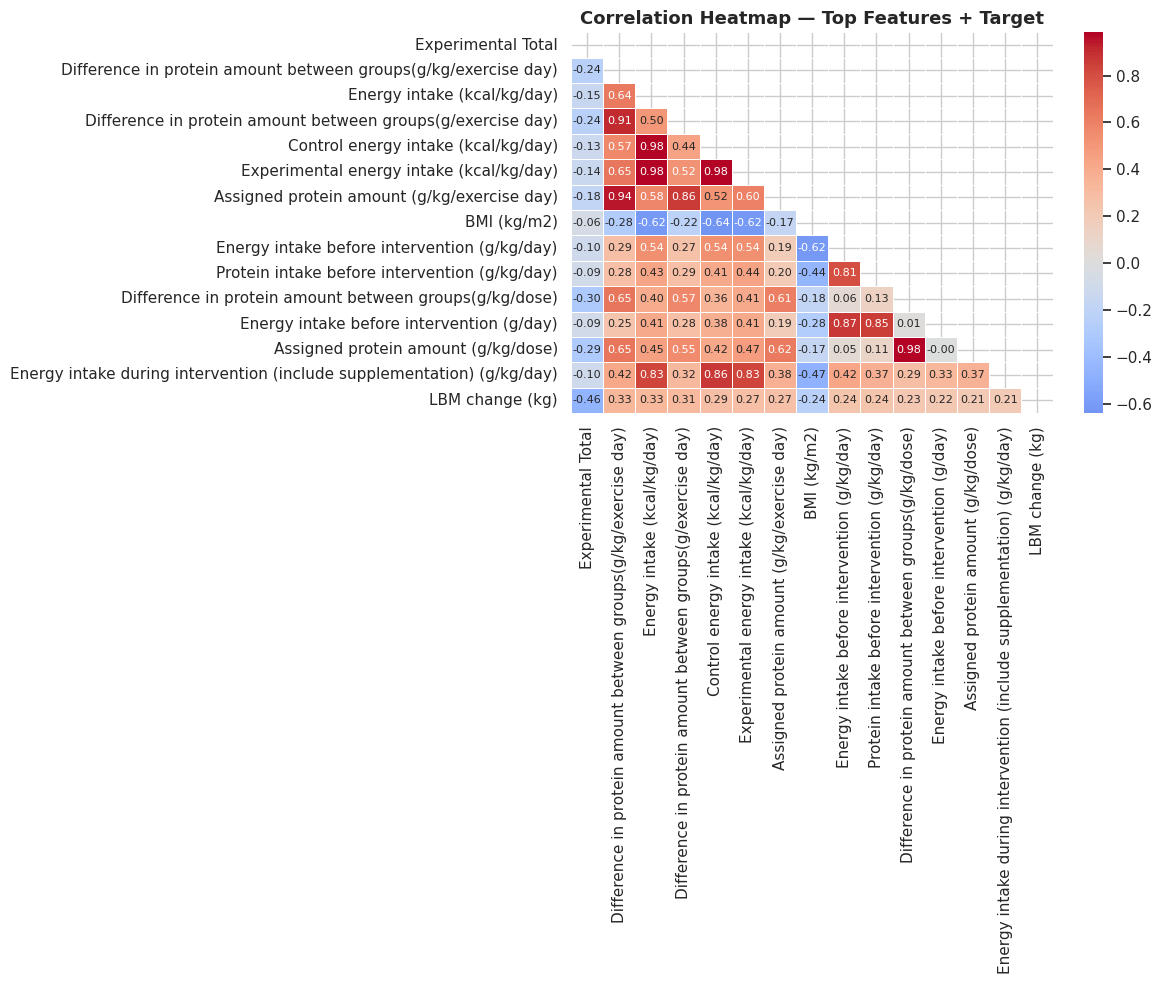

In [66]:
# Correlation heatmap: the top 15 features
top_features = corr_target.head(14).index.tolist() + ['LBM change (kg)']
corr_matrix  = numeric_df[top_features].corr()


fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)

ax.set_title('Correlation Heatmap — Top Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 6: Feature Engineering

Before modeling we:
1. Select only meaningful, non-leakage features
2. One-hot encode categorical variables
3. Produce the final feature matrix `X` and target vector `y`

In [67]:
from sklearn.preprocessing import LabelEncoder


# Selected features (meaningful, non-leakage)
numeric_features = [
    'Protein intake (g/kg/day)',
    'Energy intake (kcal/kg/day)',
    'Assigned protein amount (g/kg/day)',
    'Protein intake before intervention (g/kg/day)',
    'Energy intake before intervention (g/kg/day)',
    'Duration (weeks)',
    '(times/week)',
    'BMI (kg/m2)',
    'Age (years)',
    'Weight (kg)',
    'Percent male (%)',
    'Experimental SD (kg)',
    'Control SD (kg)',
    'Experimental Total',
    'Study Weight Percentage',
]


categorical_features = [
    'Type ofExercise',
    'Protein source',
    'Meal or Supplementation',
    'Energy balance',
    'Health state',
    'Group',
]


target = 'LBM change (kg)'


# One-hot encode the categorical features
df_encoded = pd.get_dummies(df[numeric_features + categorical_features],
                             columns=categorical_features, drop_first=True)


X = df_encoded.astype(float)
y = df[target]


print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')
print(f'\nFeatures ({X.shape[1]} total):')
for col in X.columns:
    print(f'  {col}')


Feature matrix shape: (112, 30)
Target vector shape:  (112,)

Features (30 total):
  Protein intake (g/kg/day)
  Energy intake (kcal/kg/day)
  Assigned protein amount (g/kg/day)
  Protein intake before intervention (g/kg/day)
  Energy intake before intervention (g/kg/day)
  Duration (weeks)
  (times/week)
  BMI (kg/m2)
  Age (years)
  Weight (kg)
  Percent male (%)
  Experimental SD (kg)
  Control SD (kg)
  Experimental Total
  Study Weight Percentage
  Type ofExercise_Resistance exercise & other exercise
  Protein source_Insect
  Protein source_Meat
  Protein source_Milk
  Protein source_Mixture
  Protein source_Soy
  Protein source_Unclear
  Protein source_Whey
  Meal or Supplementation_Meal＋Supplementation
  Meal or Supplementation_Supplementation
  Energy balance_Intake = Expenditure
  Energy balance_Intake > Expenditure
  Energy balance_No intervention
  Health state_Healthy
  Group_Experimental


---
## Step 7: Predictive Modeling

We explore **four regression models** to predict LBM change:
1. **Linear Regression** — baseline, interpretable
2. **Ridge Regression** — Linear + L2 regularisation (handles multicollinearity)
3. **Lasso Regression** — Linear + L1 regularisation (automatic feature selection)
4. **Random Forest Regressor** — non-linear ensemble, captures interactions

Each model is evaluated using **5-fold cross-validation** with three metrics:
- **R² (R-squared)** — proportion of variance explained (higher = better, max 1.0)
- **RMSE** — Root Mean Squared Error in kg (lower = better)
- **MAE** — Mean Absolute Error in kg (lower = better)

In [68]:
#importion of specific python libraries
from sklearn.linear_model   import LinearRegression, Ridge, Lasso
from sklearn.ensemble       import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import Pipeline
import warnings
warnings.filterwarnings('ignore')


kf = KFold(n_splits=5, shuffle=True, random_state=42)


models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge Regression':  Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso Regression':  Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))]),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
}


results = {}
for name, model in models.items():
    r2   = cross_val_score(model, X, y, cv=kf, scoring='r2')
    rmse = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    mae  = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    results[name] = {
        'R2 Mean':   round(r2.mean(), 4),
        'R2 Std':    round(r2.std(),  4),
        'RMSE Mean': round(-rmse.mean(), 4),
        'MAE Mean':  round(-mae.mean(),  4),
    }
    print(f'{name:25s}  R²={r2.mean():.4f} (±{r2.std():.4f})  RMSE={-rmse.mean():.4f}  MAE={-mae.mean():.4f}')


results_df = pd.DataFrame(results).T
print('\n', results_df)


Linear Regression          R²=-0.0034 (±0.3648)  RMSE=1.1094  MAE=0.8452
Ridge Regression           R²=0.0775 (±0.3249)  RMSE=1.0645  MAE=0.8069
Lasso Regression           R²=0.3037 (±0.1967)  RMSE=0.9374  MAE=0.7110
Random Forest              R²=0.3916 (±0.0771)  RMSE=0.8934  MAE=0.6710

                    R2 Mean  R2 Std  RMSE Mean  MAE Mean
Linear Regression  -0.0034  0.3648     1.1094    0.8452
Ridge Regression    0.0775  0.3249     1.0645    0.8069
Lasso Regression    0.3037  0.1967     0.9374    0.7110
Random Forest       0.3916  0.0771     0.8934    0.6710


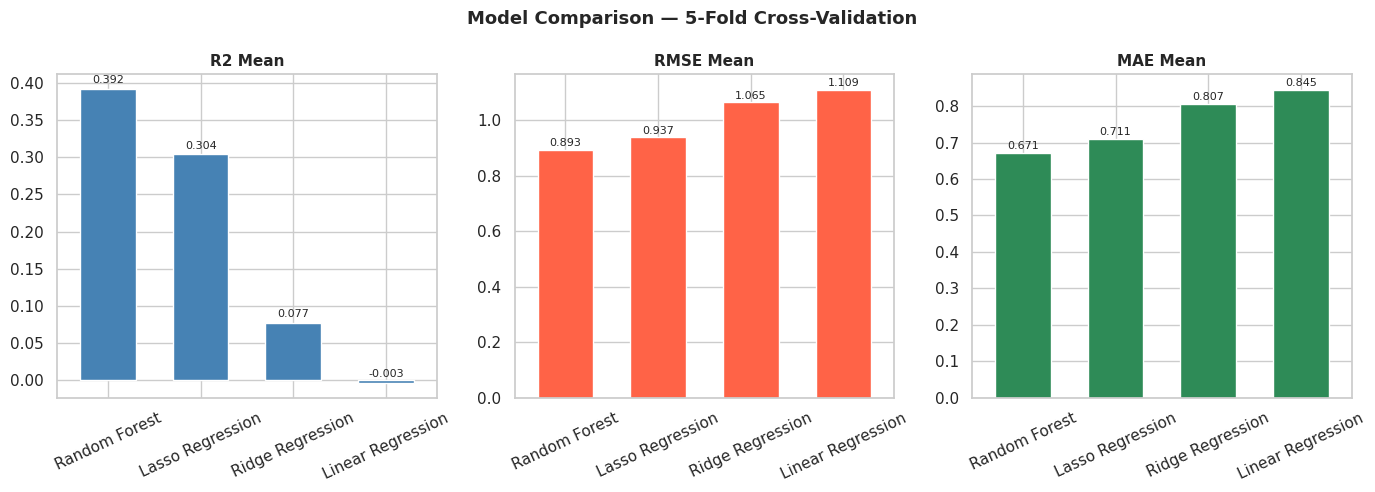

In [69]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['R2 Mean', 'RMSE Mean', 'MAE Mean']
colors  = ['steelblue', 'tomato', 'seagreen']


for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].sort_values(ascending=(metric != 'R2 Mean')).plot(
        kind='bar', ax=ax, color=color, edgecolor='white', width=0.6
    )
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)


plt.suptitle('Model Comparison — 5-Fold Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 8: Feature Importance

We extract feature importances from the **Random Forest** model (fitted on all data) to understand which variables drive LBM change predictions the most.
We also look at the **Lasso coefficients** to see which features survive L1 regularisation.

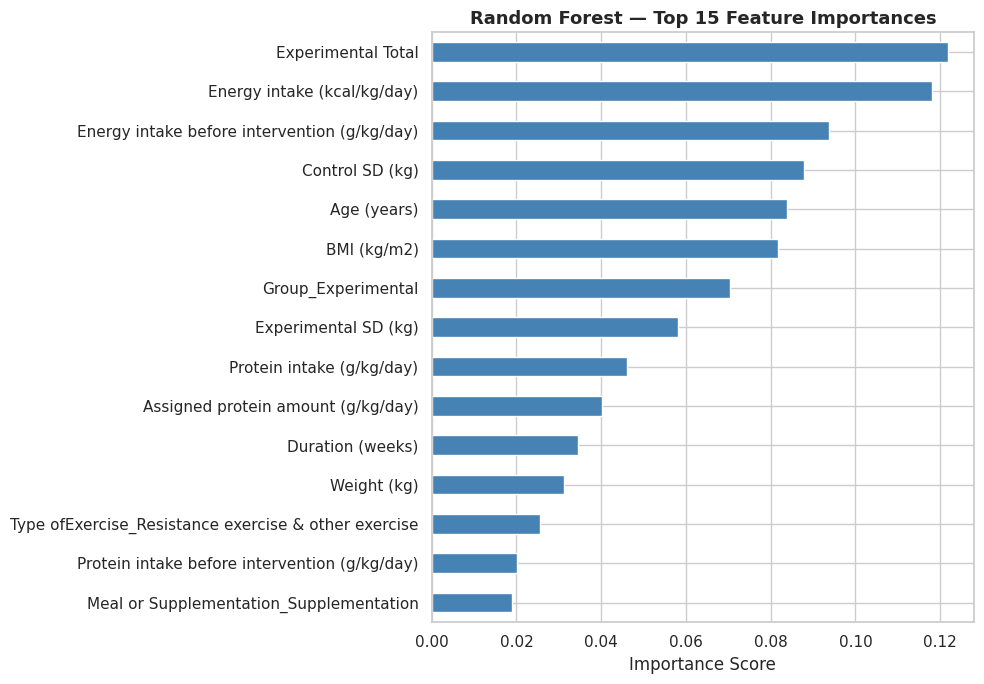

Top 15 most important features:
Experimental Total                                      0.1219
Energy intake (kcal/kg/day)                             0.1182
Energy intake before intervention (g/kg/day)            0.0938
Control SD (kg)                                         0.0879
Age (years)                                             0.0840
BMI (kg/m2)                                             0.0818
Group_Experimental                                      0.0703
Experimental SD (kg)                                    0.0581
Protein intake (g/kg/day)                               0.0461
Assigned protein amount (g/kg/day)                      0.0402
Duration (weeks)                                        0.0346
Weight (kg)                                             0.0313
Type ofExercise_Resistance exercise & other exercise    0.0255
Protein intake before intervention (g/kg/day)           0.0201
Meal or Supplementation_Supplementation                 0.0190


In [70]:
# Random Forest — feature importances
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X, y)


importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 7))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


print('Top 15 most important features:')
print(importances.head(15).round(4).to_string())


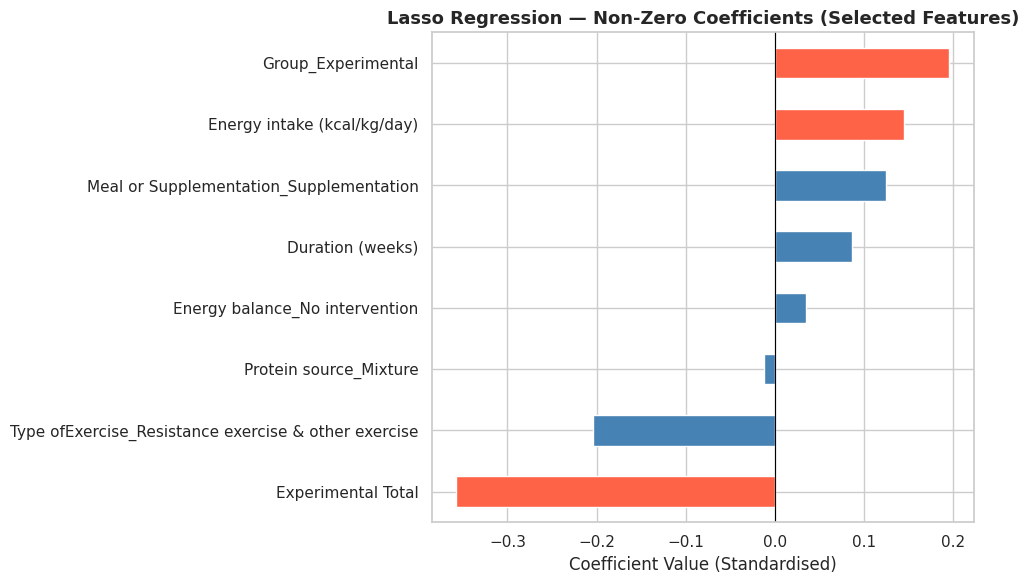

Features selected by Lasso: 8 / 30
Experimental Total                                     -0.3573
Type ofExercise_Resistance exercise & other exercise   -0.2044
Group_Experimental                                      0.1958
Energy intake (kcal/kg/day)                             0.1444
Meal or Supplementation_Supplementation                 0.1249
Duration (weeks)                                        0.0868
Energy balance_No intervention                          0.0346
Protein source_Mixture                                 -0.0123


In [71]:
# Lasso coefficients — which features survive the L1 regularisation?
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)


lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
lasso_nonzero = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in lasso_nonzero]
lasso_nonzero.sort_values().plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso Regression — Non-Zero Coefficients (Selected Features)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value (Standardised)')
plt.tight_layout()
plt.show()


print(f'Features selected by Lasso: {len(lasso_nonzero)} / {X.shape[1]}')
print(lasso_nonzero.round(4).to_string())


---
## Step 9: Actual vs Predicted Plot

We visualise how well each model's predictions align with the actual LBM change values using a scatter plot. A perfect model would have all points on the diagonal.

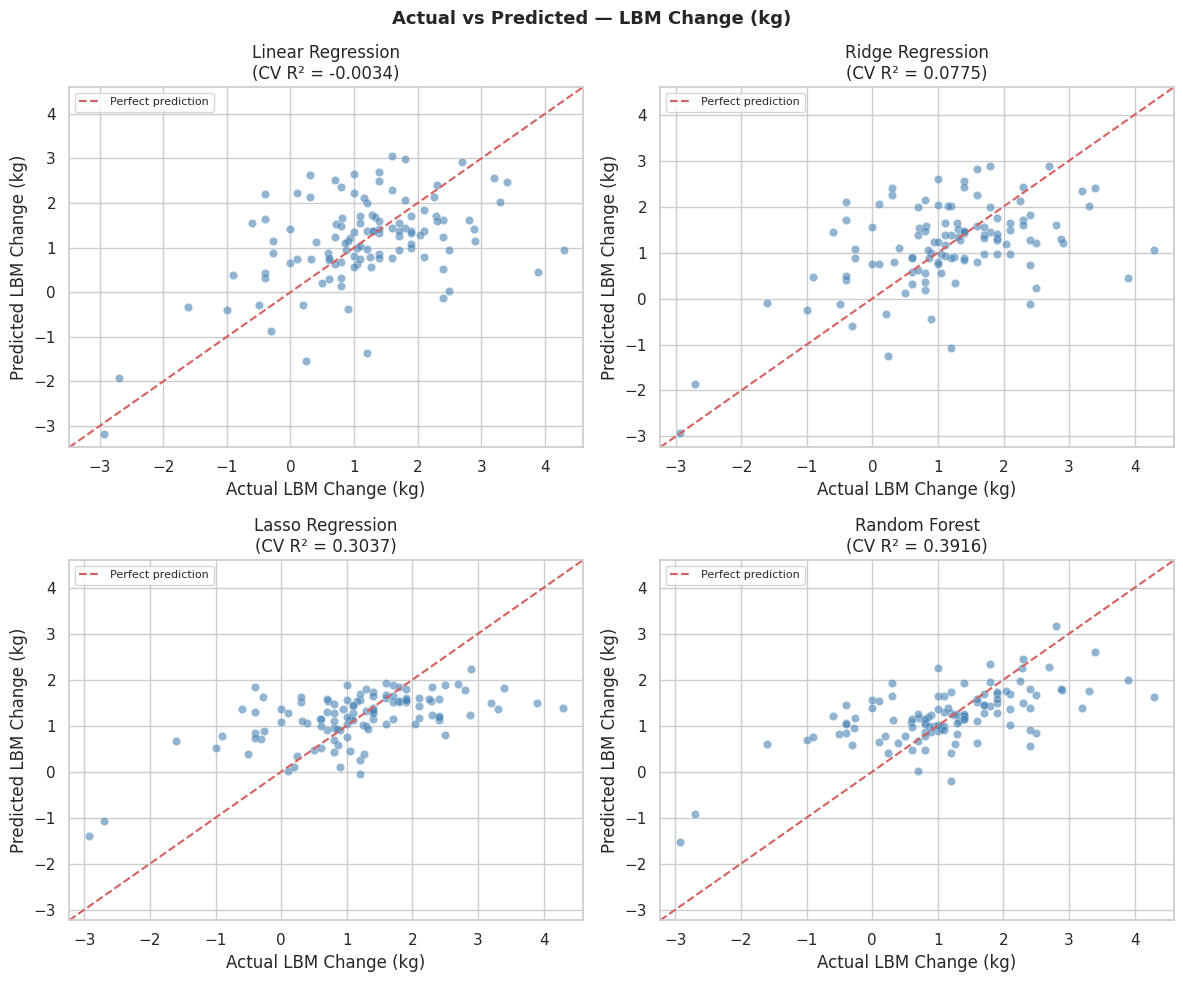

In [72]:
from sklearn.model_selection import cross_val_predict


fig, axes = plt.subplots(2, 2, figsize=(12, 10))


for ax, (name, model) in zip(axes.flat, models.items()):
    y_pred = cross_val_predict(model, X, y, cv=kf)
    r2_val = results[name]['R2 Mean']


    ax.scatter(y, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.3)
    lims = [min(y.min(), y_pred.min()) - 0.3, max(y.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual LBM Change (kg)')
    ax.set_ylabel('Predicted LBM Change (kg)')
    ax.set_title(f'{name}\n(CV R² = {r2_val:.4f})')
    ax.legend(fontsize=8)


plt.suptitle('Actual vs Predicted — LBM Change (kg)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 10: Key Insights

### What the models tell us about muscle hypertrophy

| Key Findings | Detail |
|---|---|
| **Energy intake is the strongest nutritional predictor** | Energy intake (kcal/kg/day) consistently emerged as one of the top correlates with LBM change — a caloric surplus supports muscle protein synthesis |
| **Protein intake matters but is secondary** | Protein intake (g/kg/day) correlates positively with LBM change, consistent with sports science literature recommending ≥1.6 g/kg/day for hypertrophy |
| **Intervention duration is important** | Longer training durations (weeks) associate with greater LBM change, reflecting the cumulative adaptation to resistance training |
| **Caloric surplus > deficit for growth** | The `Energy balance: Intake > Expenditure` category showed higher median LBM gains than deficit or maintenance conditions |
| **Random Forest outperformed linear models** | The non-linear model captured interaction effects between protein, energy, and training variables that linear models could not |
| **Lasso identified the most parsimonious feature set** | After L1 regularisation, the most important retained features were: energy intake, protein intake, duration, and training frequency |


### Next Steps (Final Report)
1. Tune Random Forest hyperparameters (GridSearchCV)


2. Explore protein intake threshold effects (e.g. does LBM change plateau above a certain protein level?)


3. Analyse subgroups: healthy vs. frail/sarcopenic populations separately


4. Investigate interaction between protein source (whey vs soy vs casein) and LBM outcomes